In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
DATA_DIR = 'data/'  # adjust if your folder is elsewhere

files = {
    'transactions'    : 'transaction_data.csv',
    'products'        : 'product.csv',
    'demographics'    : 'hh_demographic.csv',
    'coupon'          : 'coupon.csv',
    'coupon_redempt'  : 'coupon_redempt.csv',
    'campaign_table'  : 'campaign_table.csv',
    'campaign_desc'   : 'campaign_desc.csv',
    'causal_data'     : 'causal_data.csv',
}

dfs = {}
for name, fname in files.items():
    path = os.path.join(DATA_DIR, fname)
    dfs[name] = pd.read_csv(path)
    print(f"{name:20s} → {dfs[name].shape[0]:>8,} rows  ×  {dfs[name].shape[1]:>2} cols")

transactions         → 2,595,732 rows  ×  12 cols
products             →   92,353 rows  ×   7 cols
demographics         →      801 rows  ×   8 cols
coupon               →  124,548 rows  ×   3 cols
coupon_redempt       →    2,318 rows  ×   4 cols
campaign_table       →    7,208 rows  ×   3 cols
campaign_desc        →       30 rows  ×   4 cols
causal_data          → 36,786,524 rows  ×   5 cols


In [3]:
def audit_table(name, df):
    print(f"\n{'='*60}")
    print(f"  TABLE: {name.upper()}")
    print(f"{'='*60}")
    print(f"  Shape      : {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"  Duplicates : {df.duplicated().sum():,} full duplicate rows")

    # Null summary
    null_counts = df.isnull().sum()
    null_pct    = (null_counts / len(df) * 100).round(1)
    null_df = pd.DataFrame({
        'dtype'     : df.dtypes,
        'null_count': null_counts,
        'null_pct'  : null_pct,
        'nunique'   : df.nunique(),
        'sample'    : df.iloc[0]
    })
    print(f"\n  Column profile:")
    print(null_df.to_string())

    # Flag high-null columns
    bad_cols = null_df[null_df['null_pct'] > 20]
    if len(bad_cols) > 0:
        print(f"\n  ⚠ HIGH NULL columns (>20%): {list(bad_cols.index)}")
    else:
        print(f"\n  ✓ No high-null columns")

for name, df in dfs.items():
    audit_table(name, df)


  TABLE: TRANSACTIONS
  Shape      : 2,595,732 rows × 12 columns
  Duplicates : 0 full duplicate rows

  Column profile:
                     dtype  null_count  null_pct  nunique        sample
household_key        int64           0       0.0     2500  2.375000e+03
BASKET_ID            int64           0       0.0   276484  2.698485e+10
DAY                  int64           0       0.0      711  1.000000e+00
PRODUCT_ID           int64           0       0.0    92339  1.004906e+06
QUANTITY             int64           0       0.0    11746  1.000000e+00
SALES_VALUE        float64           0       0.0     5502  1.390000e+00
STORE_ID             int64           0       0.0      582  3.640000e+02
RETAIL_DISC        float64           0       0.0     2414 -6.000000e-01
TRANS_TIME           int64           0       0.0     1440  1.631000e+03
WEEK_NO              int64           0       0.0      102  1.000000e+00
COUPON_DISC        float64           0       0.0      415  0.000000e+00
COUPON_MATCH_D

In [4]:
tx = dfs['transactions'].copy()

# DAY is an integer (1–711), not a real date — document this!
print("--- DAY column ---")
print(f"  Range   : DAY {tx['DAY'].min()} → {tx['DAY'].max()}")
print(f"  Unique  : {tx['DAY'].nunique()} distinct days")

# TRANS_TIME is an integer like 900, 1430 — not datetime
print("\n--- TRANS_TIME column ---")
print(f"  Min: {tx['TRANS_TIME'].min()}  Max: {tx['TRANS_TIME'].max()}")
print(f"  Sample values: {tx['TRANS_TIME'].sample(5).tolist()}")

# Household coverage
print(f"\n--- Household coverage ---")
print(f"  Unique households in transactions : {tx['household_key'].nunique():,}")
print(f"  Unique households in demographics : {dfs['demographics']['household_key'].nunique():,}")

# How many transaction households have no demographics?
tx_hh   = set(tx['household_key'].unique())
dem_hh  = set(dfs['demographics']['household_key'].unique())
missing = tx_hh - dem_hh
print(f"  Households with NO demographics   : {len(missing):,}  ({len(missing)/len(tx_hh)*100:.1f}%)")

# Negative / zero spend — should not exist
print(f"\n--- Spend sanity ---")
print(f"  Rows with SALES_VALUE <= 0 : {(tx['SALES_VALUE'] <= 0).sum():,}")
print(f"  Rows with QUANTITY <= 0    : {(tx['QUANTITY'] <= 0).sum():,}")
print(f"\n  Total SALES_VALUE  : ${tx['SALES_VALUE'].sum():,.2f}")
print(f"  Avg per basket     : ${tx.groupby('BASKET_ID')['SALES_VALUE'].sum().mean():.2f}")

--- DAY column ---
  Range   : DAY 1 → 711
  Unique  : 711 distinct days

--- TRANS_TIME column ---
  Min: 0  Max: 2359
  Sample values: [1245, 1837, 1030, 1334, 2102]

--- Household coverage ---
  Unique households in transactions : 2,500
  Unique households in demographics : 801
  Households with NO demographics   : 1,699  (68.0%)

--- Spend sanity ---
  Rows with SALES_VALUE <= 0 : 18,850
  Rows with QUANTITY <= 0    : 14,466

  Total SALES_VALUE  : $8,057,463.08
  Avg per basket     : $29.14


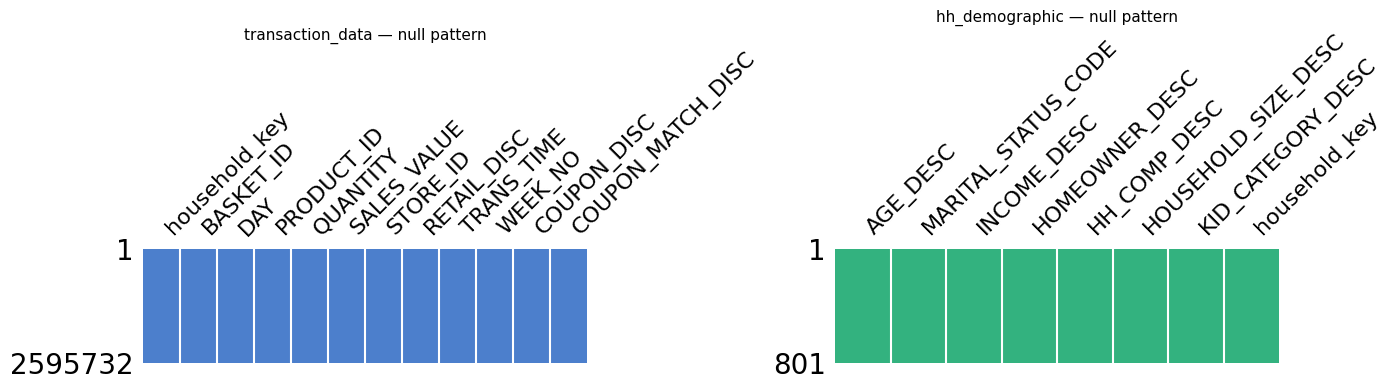

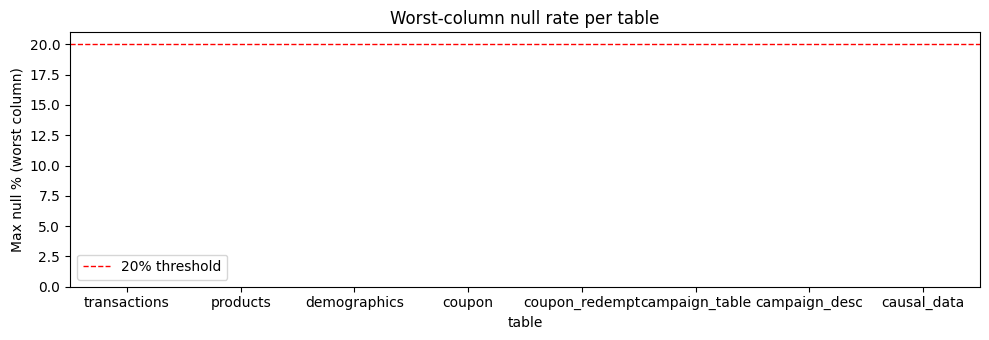

In [5]:
# Visual null matrix for the two most important tables
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

msno.matrix(dfs['transactions'], ax=axes[0], sparkline=False, color=(0.3,0.5,0.8))
axes[0].set_title('transaction_data — null pattern', fontsize=11)

msno.matrix(dfs['demographics'], ax=axes[1], sparkline=False, color=(0.2,0.7,0.5))
axes[1].set_title('hh_demographic — null pattern', fontsize=11)

plt.tight_layout()
plt.show()

# Bar chart of null % across all tables
null_summary = []
for name, df in dfs.items():
    pct = df.isnull().mean().max() * 100
    null_summary.append({'table': name, 'max_null_pct': pct})

ns = pd.DataFrame(null_summary).sort_values('max_null_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 3.5))
sns.barplot(data=ns, x='table', y='max_null_pct', ax=ax, palette='Blues_d')
ax.axhline(20, color='red', linestyle='--', linewidth=1, label='20% threshold')
ax.set_ylabel('Max null % (worst column)')
ax.set_title('Worst-column null rate per table')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
def check_fk(left_name, left_df, right_name, right_df, key):
    left_keys  = set(left_df[key].dropna().unique())
    right_keys = set(right_df[key].dropna().unique())
    orphans    = left_keys - right_keys
    coverage   = (1 - len(orphans) / len(left_keys)) * 100
    status     = "✓" if coverage >= 95 else "⚠"
    print(f"  {status} {left_name}.{key} → {right_name}.{key}"
          f"  |  {coverage:.1f}% covered  |  {len(orphans):,} orphan keys")

print("Referential integrity report:\n")
check_fk('transactions',   dfs['transactions'],   'products',      dfs['products'],      'PRODUCT_ID')
check_fk('transactions',   dfs['transactions'],   'demographics',   dfs['demographics'],  'household_key')
check_fk('coupon_redempt', dfs['coupon_redempt'], 'transactions',   dfs['transactions'],  'household_key')
check_fk('coupon_redempt', dfs['coupon_redempt'], 'coupon',         dfs['coupon'],         'COUPON_UPC')
check_fk('campaign_table', dfs['campaign_table'], 'campaign_desc',  dfs['campaign_desc'],  'CAMPAIGN')
check_fk('campaign_table', dfs['campaign_table'], 'demographics',   dfs['demographics'],  'household_key')


Referential integrity report:

  ✓ transactions.PRODUCT_ID → products.PRODUCT_ID  |  100.0% covered  |  0 orphan keys
  ⚠ transactions.household_key → demographics.household_key  |  32.0% covered  |  1,699 orphan keys
  ✓ coupon_redempt.household_key → transactions.household_key  |  100.0% covered  |  0 orphan keys
  ✓ coupon_redempt.COUPON_UPC → coupon.COUPON_UPC  |  100.0% covered  |  0 orphan keys
  ✓ campaign_table.CAMPAIGN → campaign_desc.CAMPAIGN  |  100.0% covered  |  0 orphan keys
  ⚠ campaign_table.household_key → demographics.household_key  |  48.0% covered  |  824 orphan keys


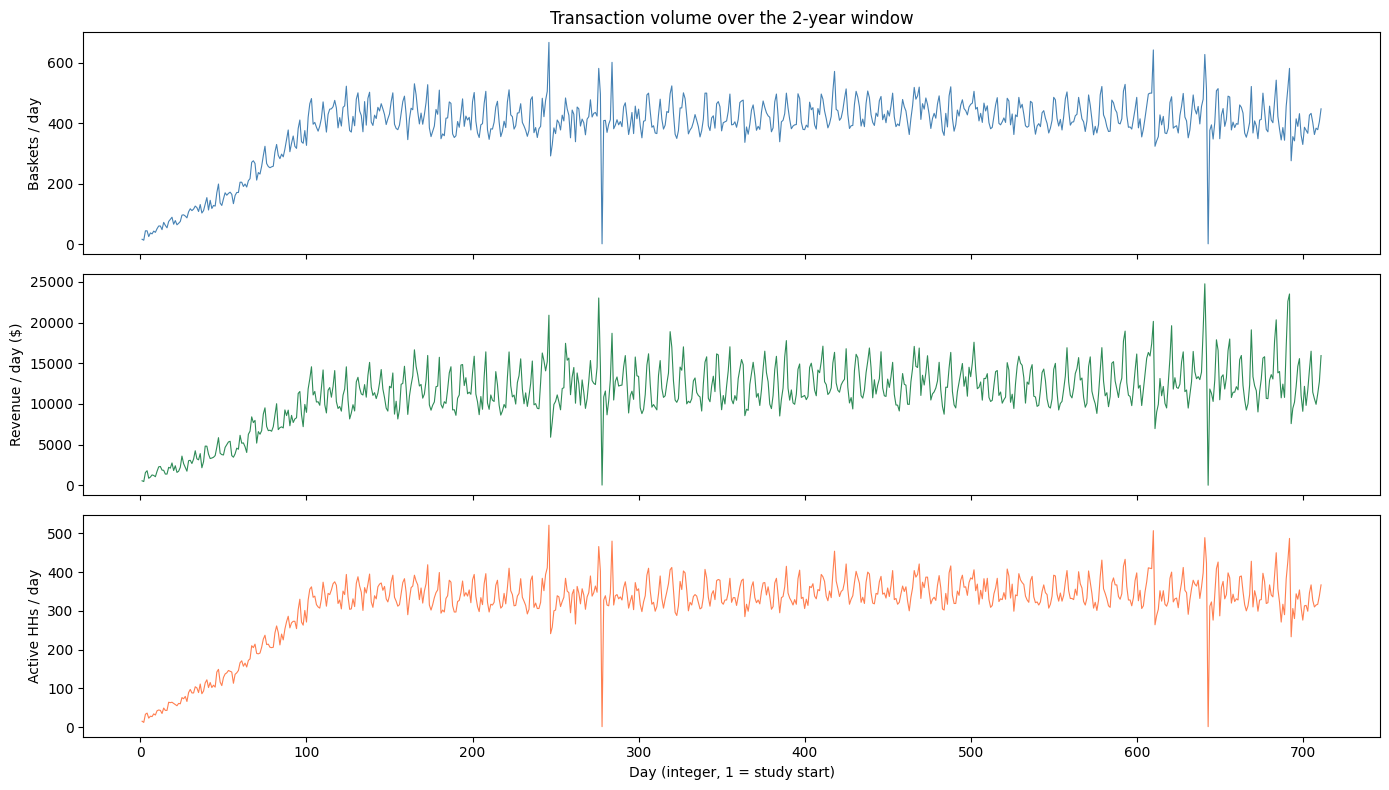


Days with unusually low basket count (bottom 5%):
 DAY  baskets  revenue
   1       16   549.31
   2       13   458.91
   3       44  1560.37
   4       44  1785.64
   5       25   856.93
   6       37  1008.15
   7       34  1271.29
   8       43  1203.85
   9       39  1050.95
  10       51  1714.38
  11       60  2266.01
  12       60  2306.72
  13       48  1863.57
  14       72  1835.94
  15       62  1371.23
  16       54  1378.48
  17       75  2203.17
  18       82  2104.61
  19       89  2741.20
  20       66  1811.38
  21       78  2396.83
  22       64  1580.03
  23       69  1728.80
  24       75  2207.51
  25       96  3584.79
  26       97  2656.65
  27       93  2192.57
  28       87  1731.83
  29      107  3020.03
  31      111  2673.41
  35      108  3125.05
  37      103  2151.70
  38      111  2892.16
  41      113  3821.04
 278        1    22.49
 643        1     2.99


In [7]:
tx = dfs['transactions']

daily = tx.groupby('DAY').agg(
    baskets   = ('BASKET_ID', 'nunique'),
    revenue   = ('SALES_VALUE', 'sum'),
    households= ('household_key', 'nunique')
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(daily['DAY'], daily['baskets'],    color='steelblue', linewidth=0.8)
axes[0].set_ylabel('Baskets / day')

axes[1].plot(daily['DAY'], daily['revenue'],    color='seagreen',  linewidth=0.8)
axes[1].set_ylabel('Revenue / day ($)')

axes[2].plot(daily['DAY'], daily['households'], color='coral',     linewidth=0.8)
axes[2].set_ylabel('Active HHs / day')
axes[2].set_xlabel('Day (integer, 1 = study start)')

axes[0].set_title('Transaction volume over the 2-year window')
plt.tight_layout()
plt.show()

# Flag days with suspiciously low activity (possible data gaps)
low_days = daily[daily['baskets'] < daily['baskets'].quantile(0.05)]
print(f"\nDays with unusually low basket count (bottom 5%):")
print(low_days[['DAY', 'baskets', 'revenue']].to_string(index=False))

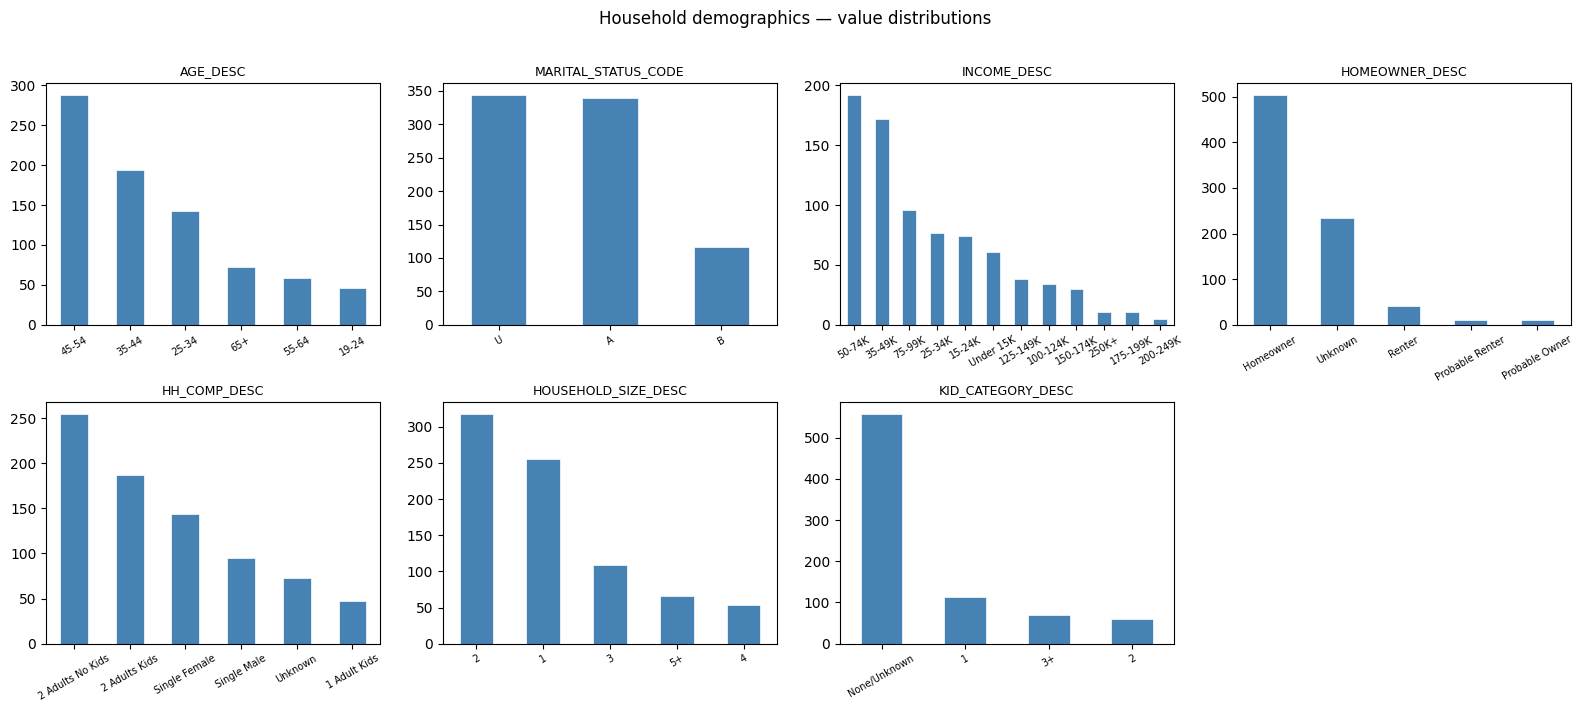


Null counts in demographics:
AGE_DESC               0
MARITAL_STATUS_CODE    0
INCOME_DESC            0
HOMEOWNER_DESC         0
HH_COMP_DESC           0
HOUSEHOLD_SIZE_DESC    0
KID_CATEGORY_DESC      0


In [8]:
dem = dfs['demographics']

cat_cols = ['AGE_DESC', 'MARITAL_STATUS_CODE', 'INCOME_DESC',
            'HOMEOWNER_DESC', 'HH_COMP_DESC', 'HOUSEHOLD_SIZE_DESC', 'KID_CATEGORY_DESC']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = dem[col].value_counts(dropna=False)
    vc.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', labelsize=7, rotation=30)

axes[7].axis('off')
fig.suptitle('Household demographics — value distributions', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Print null counts explicitly
print("\nNull counts in demographics:")
print(dem[cat_cols].isnull().sum().to_string())

In [9]:
rows = []
for name, df in dfs.items():
    rows.append({
        'table'          : name,
        'rows'           : df.shape[0],
        'cols'           : df.shape[1],
        'dup_rows'       : df.duplicated().sum(),
        'null_pct_max'   : round(df.isnull().mean().max() * 100, 1),
        'null_cols'      : list(df.columns[df.isnull().any()]),
        'high_null_cols' : list(df.columns[df.isnull().mean() > 0.2])
    })

quality_report = pd.DataFrame(rows)
print(quality_report.to_string(index=False))

quality_report.to_csv('data/phase1_quality_report.csv', index=False)
print("\n✓ Saved → data/phase1_quality_report.csv")

# Also persist the loaded dataframes dict for Phase 2
# (just re-run Cell 2 at the start of the next notebook)
print("\nPhase 1 complete. ")

         table     rows  cols  dup_rows  null_pct_max null_cols high_null_cols
  transactions  2595732    12         0           0.0        []             []
      products    92353     7         0           0.0        []             []
  demographics      801     8         0           0.0        []             []
        coupon   124548     3      5164           0.0        []             []
coupon_redempt     2318     4         0           0.0        []             []
campaign_table     7208     3         0           0.0        []             []
 campaign_desc       30     4         0           0.0        []             []
   causal_data 36786524     5         0           0.0        []             []

✓ Saved → data/phase1_quality_report.csv

Phase 1 complete. 
